In [18]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [19]:
import pandas as pd
import numpy as np
import re
import pickle
import matplotlib.pyplot as plt

In [21]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout,GRU
from tensorflow.keras.callbacks import EarlyStopping

2026-04-08 08:47:57.810601: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775638078.013176      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775638078.071131      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775638078.534248      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775638078.534293      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775638078.534296      55 computation_placer.cc:177] computation placer alr

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [28]:
print("Step 1: Loading Dataset...")
file_path = r"/kaggle/input/datasets/krishnacodesss/tweets/Tweets.csv"
df = pd.read_csv(file_path)

Step 1: Loading Dataset...


In [29]:
print("Step 2: Preprocessing Text...")

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r'\@\w+|\#', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    return text

df['clean_text'] = df['text'].apply(clean_text)
df = df[df['clean_text'].str.strip() != '']


Step 2: Preprocessing Text...


In [30]:
print("Step 3: Encoding Labels and Tokenizing...")

label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['sentiment'])

max_words = 10000
max_len = 50

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])
X = pad_sequences(sequences, maxlen=max_len)
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Step 3: Encoding Labels and Tokenizing...


In [32]:
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle)

with open('label_encoder.pickle', 'wb') as handle:
    pickle.dump(label_encoder, handle)



In [36]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [37]:
print("\nTraining GRU Model...")

gru_model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    GRU(64),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

gru_loss, gru_acc = gru_model.evaluate(X_test, y_test)
print(f"GRU Test Accuracy: {gru_acc:.4f}")



Training GRU Model...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2026-04-08 08:59:22.204484: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


310/310 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - accuracy: 0.5086 - loss: 0.9681 - val_accuracy: 0.6965 - val_loss: 0.7283
Epoch 2/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.7589 - loss: 0.6029 - val_accuracy: 0.7184 - val_loss: 0.7030
Epoch 3/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.8216 - loss: 0.4709 - val_accuracy: 0.6984 - val_loss: 0.7674
Epoch 4/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.8630 - loss: 0.3660 - val_accuracy: 0.6879 - val_loss: 0.8012
Epoch 5/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.9005 - loss: 0.2866 - val_accuracy: 0.6806 - val_loss: 0.9753
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6956 - loss: 0.7176
GRU Test Accuracy: 0.6960


In [38]:
print("\nTraining LSTM Model...")

lstm_model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    LSTM(64),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

lstm_loss, lstm_acc = lstm_model.evaluate(X_test, y_test)
print(f"LSTM Test Accuracy: {lstm_acc:.4f}")



Training LSTM Model...
Epoch 1/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.4986 - loss: 0.9736 - val_accuracy: 0.6811 - val_loss: 0.7328
Epoch 2/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.7559 - loss: 0.6055 - val_accuracy: 0.7011 - val_loss: 0.7155
Epoch 3/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.8210 - loss: 0.4759 - val_accuracy: 0.7070 - val_loss: 0.7356
Epoch 4/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.8562 - loss: 0.3924 - val_accuracy: 0.6952 - val_loss: 0.7829
Epoch 5/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.8841 - loss: 0.3270 - val_accuracy: 0.6884 - val_loss: 0.8605
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6963 - loss: 0.7310
LSTM Test Accuracy: 0.6941


In [41]:
print("\nTraining RNN Model...")

rnn_model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    SimpleRNN(64),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
rnn_loss, rnn_acc = rnn_model.evaluate(X_test, y_test)
print(f"RNN Test Accuracy: {rnn_acc:.4f}")



Training RNN Model...
Epoch 1/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.4439 - loss: 1.0418 - val_accuracy: 0.6547 - val_loss: 0.7815
Epoch 2/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.7499 - loss: 0.6292 - val_accuracy: 0.6515 - val_loss: 0.8232
Epoch 3/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8956 - loss: 0.3219 - val_accuracy: 0.6247 - val_loss: 1.0027
Epoch 4/10
310/310 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9487 - loss: 0.1656 - val_accuracy: 0.6160 - val_loss: 1.2169
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6581 - loss: 0.7841
RNN Test Accuracy: 0.6596


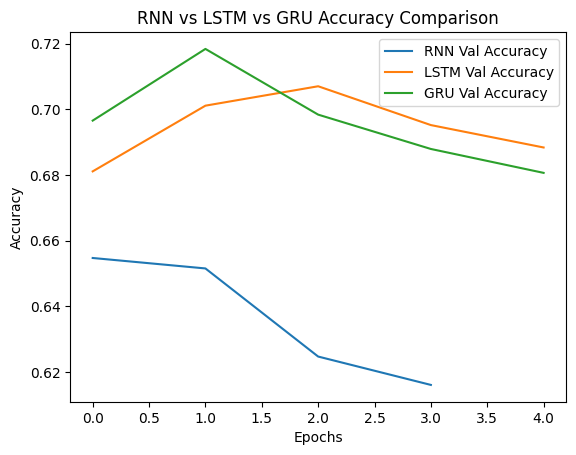


Final Comparison:
✅ GRU is the best model


In [42]:
plt.figure()

plt.plot(rnn_history.history['val_accuracy'], label='RNN Val Accuracy')
plt.plot(lstm_history.history['val_accuracy'], label='LSTM Val Accuracy')
plt.plot(gru_history.history['val_accuracy'], label='GRU Val Accuracy')

plt.title("RNN vs LSTM vs GRU Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
# =========================
# Step 7: Compare Models
# =========================
print("\nFinal Comparison:")

models = {
    "RNN": (rnn_model, rnn_acc),
    "LSTM": (lstm_model, lstm_acc),
    "GRU": (gru_model, gru_acc)
}

best_name = max(models, key=lambda x: models[x][1])
best_model = models[best_name][0]

print(f"✅ {best_name} is the best model")


In [43]:
best_model.save("best_sentiment_model.h5")

print("🔥 DONE! Best model saved as 'best_sentiment_model.h5'")

🔥 DONE! Best model saved as 'best_sentiment_model.h5'
